# DVAA datasets analysis

### Imports

In [59]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [60]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from logger import logger
from io_utils import load_run_data 
from viewers import view_stack
from correctors import LinRegCorrector, correct_stack
from plotters import *
from postpro import *

tstart_analysis = time.perf_counter()

### Inputs

In [61]:
# Data root
dataroot = '/Users/tlemaire/Documents/data/hemo2p/DVAA datasets'
analysis_type = 'opto_constrict'  # 'examples' | 'opto_constrict' | 'ori8'

# Figures directory & dictionary
figsdir = os.path.join(dataroot, 'figs')
figs = {}

# Data directory 
datadir = os.path.join(dataroot, analysis_type)
# datadir = os.path.join(dataroot, 'examples')
logger.info(f'input data directory: {datadir}')

# Define recording parameters
fps = 1 / 0.77764  # frames per second
umperpx = 1.29  # µm/pixel
logger.info(f'fps: {fps:.2f} Hz, spatial resolution: {umperpx} µm/px')

 2026/05/14 11:05:04: input data directory: /Users/tlemaire/Documents/data/hemo2p/DVAA datasets/opto_constrict
 2026/05/14 11:05:04: fps: 1.29 Hz, spatial resolution: 1.29 µm/px


### Processing parameters

In [62]:
# Initialize family of LinRegCorrector variants
correctors = {}
robusts = [False] #, True]
intercepts = [True]#, False] 
# qmax = [1, 0.2, 'adaptive']
for robust in robusts:
    for intercept in intercepts:
        # for q in qmax:
        lrc = LinRegCorrector(robust=robust, intercept=intercept) #, qmax=q)
        correctors[lrc.code] = lrc
correctors_str = '\n'.join([f'    - {k}: {v}' for k, v in correctors.items()])
logger.info(f'initialized the following correctors:\n{correctors_str}')

# dFF compuation parameters
qbase = 0.1  # quantile for fluorescence baseline computation

 2026/05/14 11:05:05: initialized the following correctors:
    - linreg: LinRegCorrector(robust=False)


### Load original stack data and ROI masks 

 2026/05/14 11:05:06: loading data from "/Users/tlemaire/Documents/data/hemo2p/DVAA datasets/opto_constrict/m028-009"
 2026/05/14 11:05:06: loading stack from existing file
 2026/05/14 11:05:07: loaded 834-frames stack with shape 512x512
 2026/05/14 11:05:07: extracting FOV using mean projection
 2026/05/14 11:05:07: loaded 212 ROIs mask
 2026/05/14 11:05:07: loading data from "/Users/tlemaire/Documents/data/hemo2p/DVAA datasets/opto_constrict/m238-008"
 2026/05/14 11:05:07: loading stack from existing file
 2026/05/14 11:05:07: loaded 601-frames stack with shape 512x512
 2026/05/14 11:05:07: extracting FOV using mean projection
 2026/05/14 11:05:07: loaded 360 ROIs mask
 2026/05/14 11:05:07: loading data from "/Users/tlemaire/Documents/data/hemo2p/DVAA datasets/opto_constrict/m292-004"
 2026/05/14 11:05:07: loading stack from existing file
 2026/05/14 11:05:07: loaded 755-frames stack with shape 512x512
 2026/05/14 11:05:07: extracting FOV using mean projection
 2026/05/14 11:05:08: l

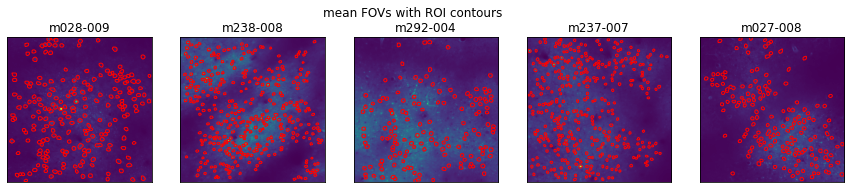

In [63]:
# List runs from sub-directories
runs = [k for k in os.listdir(datadir) if k != '.DS_Store']

# Load data from each run
rundirs = [os.path.join(datadir, run) for run in runs]
stackfpath_per_run, nframes_per_run, FOV_per_run, masks_per_run = load_run_data(rundirs)
nframes_min = min(nframes_per_run.values())

# Plot stack projection FOV and ROI contours
figtitle = 'mean FOVs with ROI contours' 
figs[figtitle] = plot_FOV_and_masks(FOV_per_run, masks_per_run, title=figtitle)

### Define frame intervals for pre, stim, and post windows

In [64]:
# Define stimulus parameters
if analysis_type == 'opto_constrict':
    # Opti-constriction analysis: stimulus = 100 ms pulses every 3 frames,
    # from frame 301 to 403 included 
    istim = np.arange(301, 403 + 1, 3)
    framesdict = {
        'pre': np.arange(0, istim[0]),
        'stim': np.arange(istim[0], istim[-1] + 1),
        'post': np.arange(istim[-1] + 1, nframes_min)
    }
    framesdict['nostim'] = np.concatenate([framesdict['pre'], framesdict['post']])
    istimbounds = [(istim[0], istim[-1])]
    nmax = None
    npertrial = None

elif analysis_type == 'ori8':
    # Ori8 analysis: 8 orientations x 6 repeats = 48 trials, 
    # 50 frames of blank and 10 frames of stimulus for each trial
    norientations = 8
    nrepeats = 6
    ntrials = norientations * nrepeats
    nframes_nostim = 50
    nframes_stim = 10
    npertrial = nframes_nostim + nframes_stim
    istart =  np.arange(ntrials) * npertrial
    inostim = np.add.outer(istart, np.arange(nframes_nostim))
    istim = np.add.outer(istart, np.arange(nframes_stim)) + nframes_nostim
    istimbounds = [(x[0], x[-1]) for x in istim]
    istim = istim.flatten()
    inostim = inostim.flatten()
    framesdict = {
        'nostim': inostim,
        'stim': istim,
    }
    nmax = ntrials * npertrial

### Apply linear regression correctors and compare original vs corrected stacks

In [65]:
# Initial 2-level dictionary or stacks dictionary per run
stackfpath_dict_per_run = {}

# For each run
for run, stackfpath in stackfpath_per_run.items(): 
    # Initialize stacks dictionary
    stackfpath_dict_per_run[run] = {'original': stackfpath}

    # For each correction type
    for k, lrc in correctors.items():
        # Correct stack
        stackfpath_dict_per_run[run][lrc.code] = correct_stack(lrc, stackfpath)

# View last run
view_stack(
    stackfpath_dict_per_run[run], 
    ilabels={'stim': istim}, 
    title=run,
)

 2026/05/14 11:05:16: loading "stack_linreg.tif" output stack from "/Users/tlemaire/Documents/data/hemo2p/DVAA datasets/opto_constrict/m028-009/stacks"
 2026/05/14 11:05:16: loading "stack_linreg.tif" output stack from "/Users/tlemaire/Documents/data/hemo2p/DVAA datasets/opto_constrict/m238-008/stacks"
 2026/05/14 11:05:17: loading "stack_linreg.tif" output stack from "/Users/tlemaire/Documents/data/hemo2p/DVAA datasets/opto_constrict/m292-004/stacks"
 2026/05/14 11:05:17: loading "stack_linreg.tif" output stack from "/Users/tlemaire/Documents/data/hemo2p/DVAA datasets/opto_constrict/m237-007/stacks"
 2026/05/14 11:05:17: loading "stack_linreg.tif" output stack from "/Users/tlemaire/Documents/data/hemo2p/DVAA datasets/opto_constrict/m027-008/stacks"
 2026/05/14 11:05:17: initializing stack viewer
 2026/05/14 11:05:17: stack size: (830, 512, 512)
 2026/05/14 11:05:17: computing stack dynamic range across frames 0 - 829...


100%|██████████| 830/830 [00:00<00:00, 2075.39it/s]

 2026/05/14 11:05:17: stack dynamic range range: 0 - 9693


 2026/05/14 11:05:17: computing stack dynamic range across frames 0 - 829...


100%|██████████| 830/830 [00:00<00:00, 2772.80it/s]

 2026/05/14 11:05:18: stack dynamic range range: 1 - 9866
 2026/05/14 11:05:18: rendering stack view...


### Compute F and dFF traces for FOV-average and ROIs, across all stacks

In [66]:
# Initialize 2-level fluorescence traces dictionaries
F_per_run = {}
dFF_per_run = {}

# Compute dF/F traces
def mybasefunc(s):
    return s.quantile(qbase)
mybasefunc.__name__ = f'{qbase * 100:.0f}th_percentile'

# For each run
for run, stackfpath_dict in stackfpath_dict_per_run.items():
    logger.info(f'Extracting traces for run {run}...')
    # Extract fluorescence traces from stacks
    F_per_run[run] = extract_traces_df_from_stack(
        stackfpath_dict, masks=masks_per_run[run], nmax=nmax, npertrial=npertrial)
    if analysis_type == 'ori8':
        wroll = 101
    else:
        wroll = None
    dFF_per_run[run] = compute_dff(F_per_run[run], wroll=wroll, basefunc=mybasefunc)

 2026/05/14 11:05:24: Extracting traces for run m028-009...
 2026/05/14 11:05:24: processing original stack...
 2026/05/14 11:05:24: computing FOV-mean trace over 834 frames
 2026/05/14 11:05:24: computing mean traces for 212 ROIs
 2026/05/14 11:05:25: processing linreg stack...
 2026/05/14 11:05:25: computing FOV-mean trace over 834 frames
 2026/05/14 11:05:26: computing mean traces for 212 ROIs
 2026/05/14 11:05:26: computing dFF across ['kind']
 2026/05/14 11:05:26: computing static F0 using 10th_percentile function
 2026/05/14 11:05:27: computing dF/F traces
 2026/05/14 11:05:27: computing static F0 using 10th_percentile function
 2026/05/14 11:05:27: computing dF/F traces
 2026/05/14 11:05:27: Extracting traces for run m238-008...
 2026/05/14 11:05:27: processing original stack...
 2026/05/14 11:05:27: computing FOV-mean trace over 601 frames
 2026/05/14 11:05:27: computing mean traces for 360 ROIs
 2026/05/14 11:05:28: processing linreg stack...
 2026/05/14 11:05:28: computing FO

### Compute ROI-specific baseline fluoresence levels

 2026/05/14 11:05:34: working on run m028-009
 2026/05/14 11:05:34: working on run m238-008
 2026/05/14 11:05:34: working on run m292-004
 2026/05/14 11:05:34: working on run m237-007
 2026/05/14 11:05:34: working on run m027-008


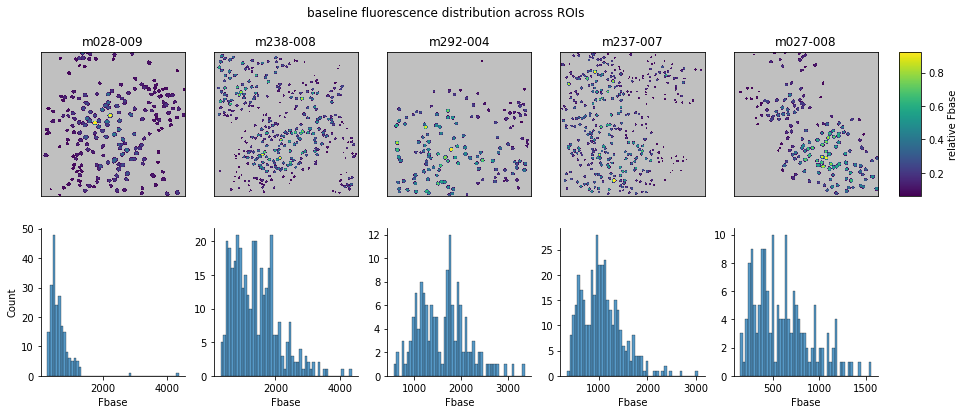

In [67]:
# Plot baseline fluorescence distribution and spatial distribution
fig, axes = plt.subplots(2, len(runs), figsize=(3 * len(runs), 6))
fig.suptitle('baseline fluorescence distribution across ROIs')

Fbasedict = {}
for axcol, (run, F) in zip(axes.T, F_per_run.items()):
    logger.info(f'working on run {run}')

    # Compute baseline fluorescence of each ROI from "no-stim" intervals of original stack
    Fbase = F.loc[pd.IndexSlice['original', framesdict['nostim']], :].quantile(0.1, axis=0).iloc[1:]
    Fbase.index = pd.to_numeric(Fbase.index.str.strip('ROI')) - 1
    Fbase.name = 'Fbase'
    Fbase.index.name = 'ROI'
    Fbasedict[run] = Fbase
    
    # Compute relative Fbase
    rel_Fbase = (Fbase - Fbase.min()) / (Fbase.max() - Fbase.min())

    # Plot map of ROIS with color-coded relative Fbase
    ax = axcol[0]
    ax.set_title(run)
    basemask = masks_per_run[run].copy().astype(float)
    for iROI, rel_fb in rel_Fbase.items():
        basemask[basemask == iROI + 1] = rel_fb
    cmap = plt.get_cmap('viridis')
    cmap.set_under('silver')
    vmin, vmax = rel_Fbase.quantile((.05, .995))
    sm = ax.imshow(basemask, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks([])
    ax.set_yticks([])

    # Plot histrogram distribution of baseline fluorescence
    ax = axcol[1]
    sns.despine(ax=ax)
    sns.histplot(Fbase, bins=50, ax=ax)

# Add colorbar on right hand side of figure
pos = axcol[0].get_position()
cbar_ax = fig.add_axes([0.92, pos.y0, 0.02, pos.height])
fig.colorbar(sm, cax=cbar_ax, label='relative Fbase')

# Remove redundant y-labels
for ax in axes[1, 1:]:
    ax.set_ylabel(None)

figs['Fbase dists'] = fig

### Compute ROI-specific change in dFF baseline between rest and stim periods, across all stacks 

 2026/05/14 11:05:35: working on run m028-009...
 2026/05/14 11:05:37: ROI dFF change distributions:


,count,mean,std,min,25%,50%,75%,max
kind,,,,,,,,
linreg,212.0,0.032011,0.159934,-0.162130,-0.046406,-0.004150,0.072113,1.443765
original,212.0,0.217188,0.216487,-0.041801,0.106295,0.178447,0.245475,2.200381


 2026/05/14 11:05:37: working on run m238-008...
 2026/05/14 11:05:39: ROI dFF change distributions:


,count,mean,std,min,25%,50%,75%,max
kind,,,,,,,,
linreg,360.0,0.050488,0.210771,-0.297833,-0.083293,0.002465,0.128777,1.118804
original,360.0,0.319170,0.334189,-0.166902,0.102716,0.239599,0.435993,1.853483


 2026/05/14 11:05:39: working on run m292-004...
 2026/05/14 11:05:40: ROI dFF change distributions:


,count,mean,std,min,25%,50%,75%,max
kind,,,,,,,,
linreg,147.0,0.001525,0.098805,-0.149403,-0.079460,-0.027031,0.080519,0.242196
original,147.0,0.213983,0.132865,0.022857,0.105613,0.177416,0.312957,0.554949


 2026/05/14 11:05:40: working on run m237-007...
 2026/05/14 11:05:42: ROI dFF change distributions:


,count,mean,std,min,25%,50%,75%,max
kind,,,,,,,,
linreg,367.0,0.020962,0.182347,-0.294530,-0.068427,-0.018121,0.080504,2.674715
original,367.0,0.341992,0.271652,-0.037222,0.206715,0.282910,0.431747,4.164302


 2026/05/14 11:05:42: working on run m027-008...
 2026/05/14 11:05:43: ROI dFF change distributions:


,count,mean,std,min,25%,50%,75%,max
kind,,,,,,,,
linreg,158.0,0.018702,0.096795,-0.176578,-0.040479,0.004496,0.057372,0.438767
original,158.0,0.243097,0.138993,0.024074,0.140175,0.213976,0.311531,0.763906


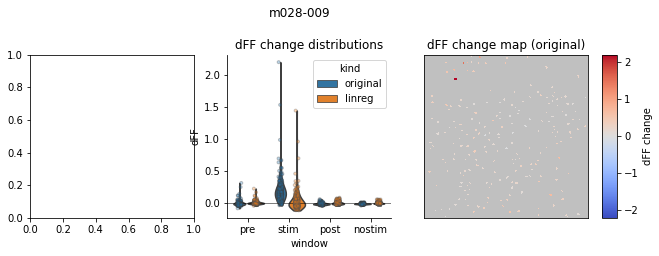

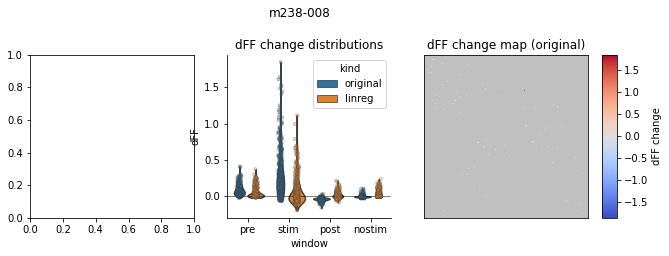

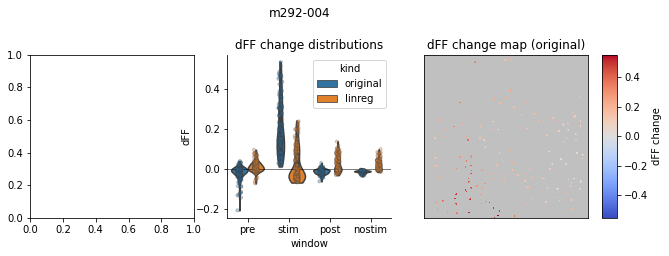

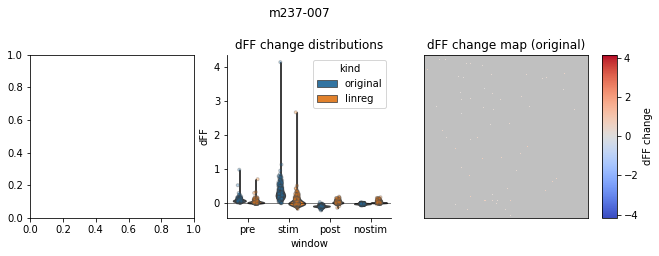

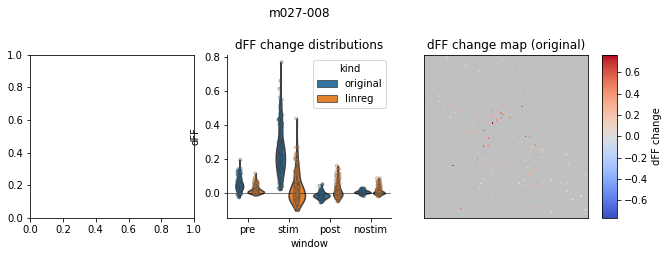

In [ ]:
ROI_dFF_change_per_run = {}
ROI_dFF_per_window_per_run = {}

# Loop through runs
for run, dFF in dFF_per_run.items():
    logger.info(f'working on run {run}...')

    # Split traces into pre, stim and post intervals
    dFF_split = {k: dFF.loc[pd.IndexSlice[:, v], :] for k, v in framesdict.items()}

    # Compute baseline dFF values for each ROI and interval
    dFF_refs = {
        k: v.groupby('kind').agg(lambda x: x.quantile(.1)) 
        for k, v in dFF_split.items()
    }

    ROI_dFF_per_window = pd.concat(dFF_refs, axis=0, names=['window']).iloc[:, 1:]
    ROI_dFF_per_window.columns = pd.to_numeric(ROI_dFF_per_window.columns.str.strip('ROI')) - 1
    ROI_dFF_per_window.columns.name = 'ROI'
    ROI_dFF_per_window = ROI_dFF_per_window.stack().rename('dFF')
    ROI_dFF_per_window_per_run[run] = ROI_dFF_per_window

    # Compute dFF change as difference between stim and no-stim values
    ROI_dFF_change = (dFF_refs['stim'] - dFF_refs['nostim']).iloc[:, 1:]
    ROI_dFF_change.columns = pd.to_numeric(ROI_dFF_change.columns.str.strip('ROI')) - 1
    ROI_dFF_change.columns.name = 'ROI'
    ROI_dFF_change = ROI_dFF_change.stack().rename('dFF change')
    ROI_dFF_change_per_run[run] = ROI_dFF_change

    fig, axes = plt.subplots(1, 3, figsize=(10, 3))
    fig.suptitle(run, y=1.1)

    # # Merge baseline fluorescence and dFF change dataframes, and remove outliers
    # df = pd.concat([Fbasedict[run], ROI_dFF_change.loc['original']], axis=1)
    # df = df[(np.abs(stats.zscore(df)) < 5).all(axis=1)]

    # Plot dFF change as a function of baseline fluorescence
    # ax = axes[0]
    # sns.despine(ax=ax)
    # ax.set_title('dFF change vs. Fbase')
    # sns.regplot(
    #     ax=ax,
    #     data=df,
    #     x='Fbase',
    #     y='dFF change',
    #     robust=True,
    # )

    # Plot distribution of dFF baseline change during stim, across corrections
    ax = axes[1]
    sns.despine(ax=ax)
    ax.set_title('dFF change distributions')
    # sns.kdeplot(
    #     ax=ax,
    #     data=ROI_dFF_change.reset_index(), 
    #     x='dFF change', 
    #     hue='kind',
    #     fill=False,
    # )
    sns.violinplot(
        ax=ax,
        data=ROI_dFF_per_window.reset_index(), 
        x='window',
        y='dFF',
        hue='kind',
        hue_order=['original'] + list(correctors.keys()),
        cut=0,
        # inner='point',
    )
    ax.axhline(0, lw=0.5, c='k')

    sns.stripplot(
        ax=ax,
        data=ROI_dFF_per_window.reset_index(), 
        x='window',
        y='dFF',
        hue='kind',
        hue_order=['original'] + list(correctors.keys()),
        dodge=True,
        marker='o',
        size=3,
        linewidth=1,
        alpha=0.3,
        legend=False,
        # cut=0,
        # inner='point',
    )

    # Plot dFF change spatial distribution from original stack
    ax = axes[2]
    ax.set_title('dFF change map (original)')
    dFFchange_mask = masks_per_run[run].copy().astype(float)
    dFFchange_mask[dFFchange_mask == 0.] = np.nan
    for iROI, dFFc in ROI_dFF_change.loc['original'].items():
        dFFchange_mask[dFFchange_mask == iROI + 1] = dFFc
    cmap = plt.get_cmap('coolwarm')
    cmap.set_bad('silver')
    absvmax = np.nanmax(np.abs(dFFchange_mask))
    sm = ax.imshow(dFFchange_mask, cmap=cmap, vmin=-absvmax, vmax=absvmax)
    ax.set_xticks([])
    ax.set_yticks([])
    pos = ax.get_position()
    cbar_ax = fig.add_axes([0.92, pos.y0, 0.02, pos.height])
    fig.colorbar(sm, cax=cbar_ax, label='dFF change')
    figs[f'dFF change dists {run}'] = fig

    # Describe ROI dFF change distributions
    logger.info('ROI dFF change distributions:')
    display(ROI_dFF_change.groupby('kind').describe())

# Transform global dFF per window dict to dataframe
ROI_dFF_per_window_per_run = pd.concat(ROI_dFF_per_window_per_run, axis=0, names=['run'])

# Save to excel file
ROI_dFF_per_window_per_run.reset_index().to_excel(
    os.path.join(dataroot, f'{analysis_type}.xlsx'),
    index=False
)

<Axes: title={'center': 'Average dFF per window'}, xlabel='window', ylabel='dFF'>

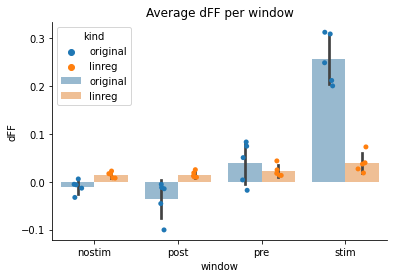

In [70]:
ROI_dFF_per_window_avg_per_run = ROI_dFF_per_window_per_run.groupby(['run', 'window', 'kind']).mean()

figs['dff per window across animals'], ax = plt.subplots(figsize=(6, 4))
sns.despine(ax=ax)
ax.set_title('Average dFF per window')
sns.stripplot(
    ax=ax,
    data=ROI_dFF_per_window_avg_per_run.reset_index(),
    x='window',
    y='dFF',
    dodge=True,
    hue='kind',
    hue_order=['original'] + list(correctors.keys()),
)
sns.barplot(
    ax=ax,
    data=ROI_dFF_per_window_avg_per_run.reset_index(),
    x='window',
    y='dFF',
    hue='kind',
    hue_order=['original'] + list(correctors.keys()),
    alpha=0.5,
    errorbar='sd',
    # legend=None
)

### Plot comparative traces for FOV average and a few random ROIs, across stacks

 2026/05/13 22:28:37: working on run m237-004
 2026/05/13 22:28:37: plotting dFF % traces for columns ['FOV', 'ROIavg']
 2026/05/13 22:28:37: plotting dFF % traces for columns ['FOV', 'ROI54', 'ROI87', 'ROI53']
 2026/05/13 22:28:38: plotting dFF % traces for columns ['FOV', 'ROI392', 'ROI130', 'ROI209']
 2026/05/13 22:28:38: plotting dFF % traces for columns ['FOV', 'ROI162', 'ROI256', 'ROI357']
 2026/05/13 22:28:38: working on run m027-004
 2026/05/13 22:28:39: plotting dFF % traces for columns ['FOV', 'ROIavg']
 2026/05/13 22:28:39: plotting dFF % traces for columns ['FOV', 'ROI5', 'ROI20', 'ROI69']
 2026/05/13 22:28:39: plotting dFF % traces for columns ['FOV', 'ROI52', 'ROI28', 'ROI31']
 2026/05/13 22:28:39: plotting dFF % traces for columns ['FOV', 'ROI118', 'ROI58', 'ROI130']
 2026/05/13 22:28:40: working on run m028-005
 2026/05/13 22:28:40: plotting dFF % traces for columns ['FOV', 'ROIavg']
 2026/05/13 22:28:40: plotting dFF % traces for columns ['FOV', 'ROI249', 'ROI316', 'RO

/opt/anaconda3/envs/usnm2p/lib/python3.8/site-packages/seaborn/axisgrid.py:1274: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=figsize)


 2026/05/13 22:28:43: plotting dFF % traces for columns ['FOV', 'ROIavg']
 2026/05/13 22:28:43: plotting dFF % traces for columns ['FOV', 'ROI353', 'ROI144', 'ROI107']
 2026/05/13 22:28:43: plotting dFF % traces for columns ['FOV', 'ROI54', 'ROI205', 'ROI222']
 2026/05/13 22:28:43: plotting dFF % traces for columns ['FOV', 'ROI484', 'ROI545', 'ROI498']


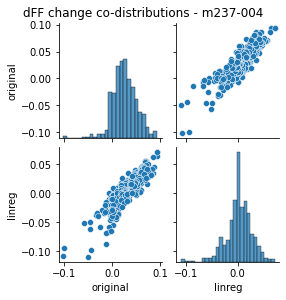

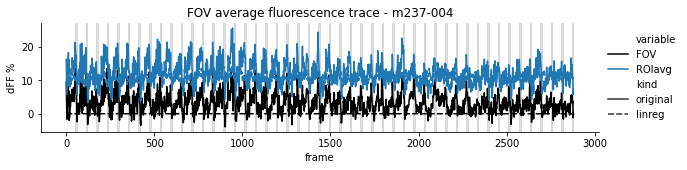

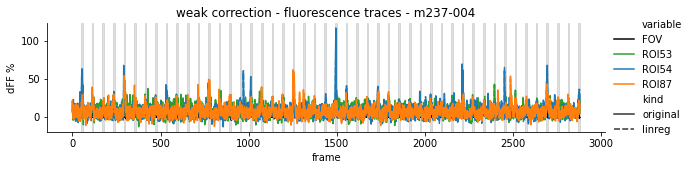

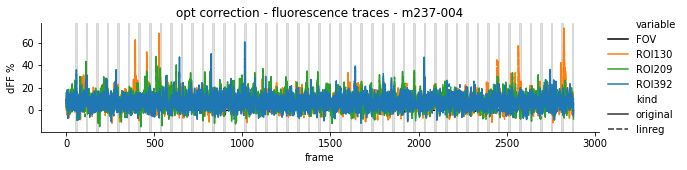

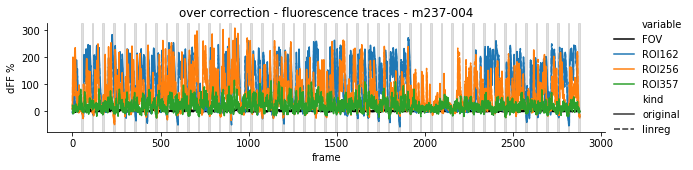

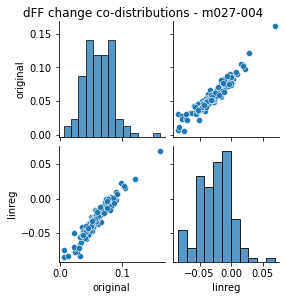

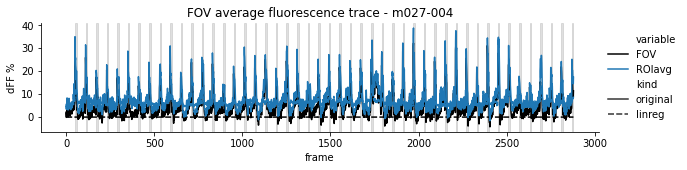

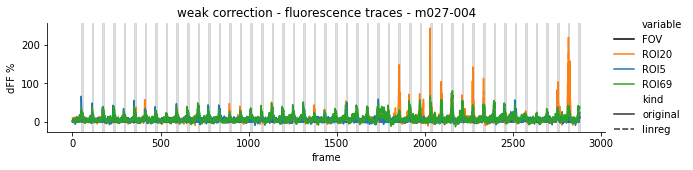

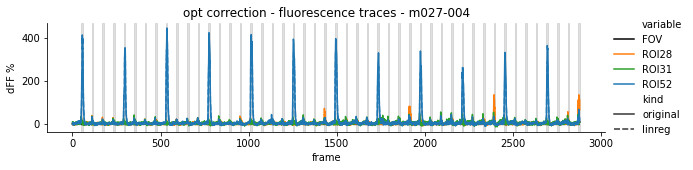

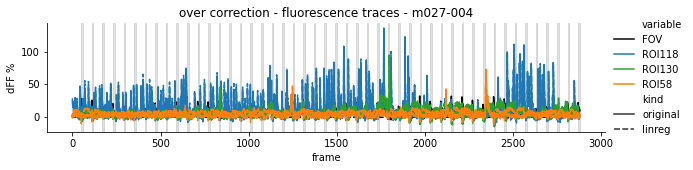

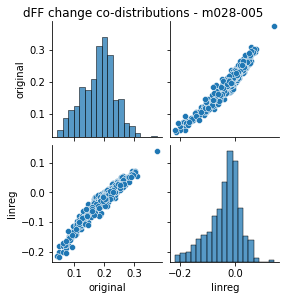

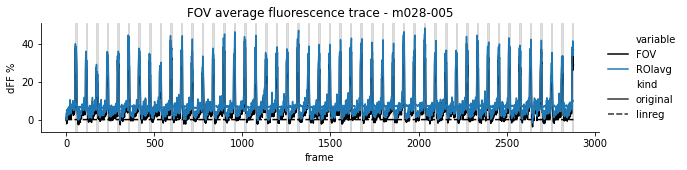

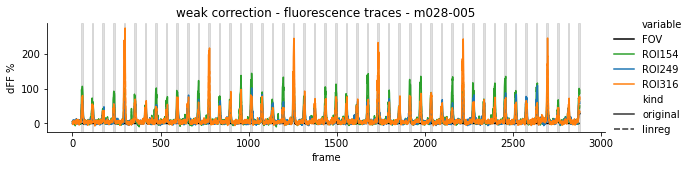

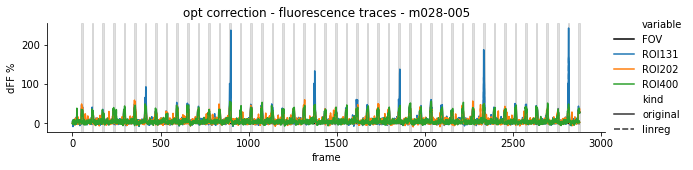

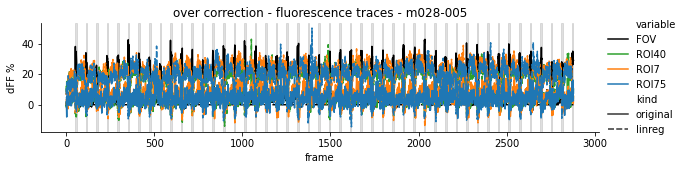

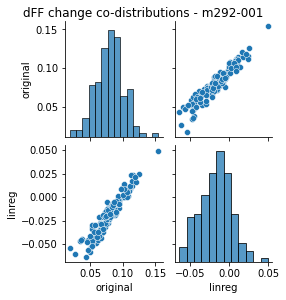

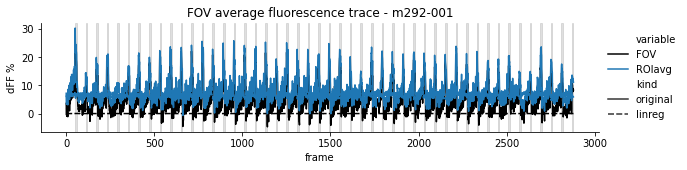

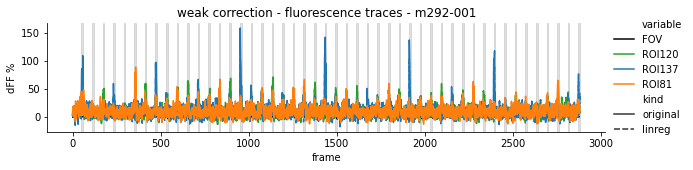

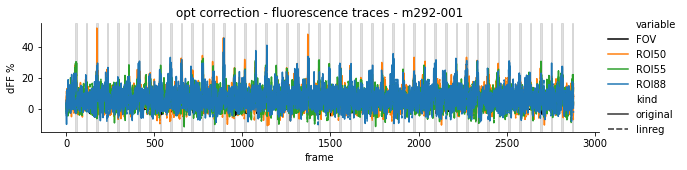

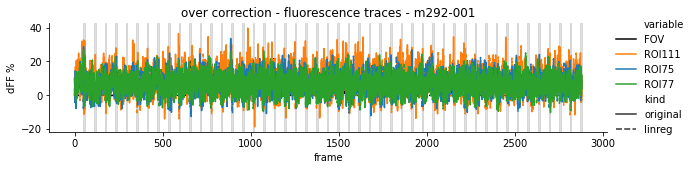

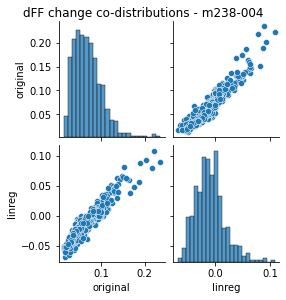

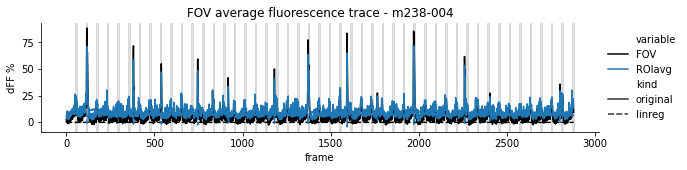

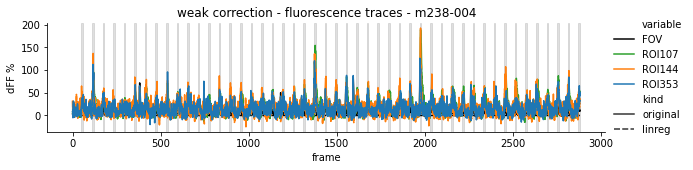

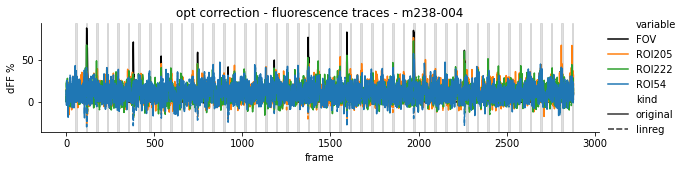

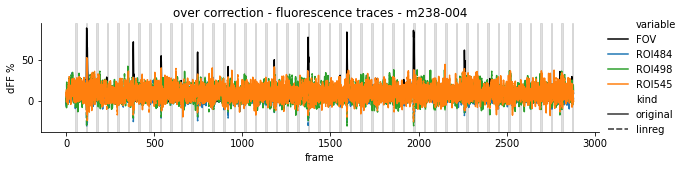

In [40]:
for run, dFF in dFF_per_run.items():

    logger.info(f'working on run {run}')
    # Assemble traces dictionary
    traces_dict = {
        # 'F': F, 
        'dFF %': dFF * 100
    }

    # Define reference correction key
    refcorrkey = 'linreg'
    traces_dict = {
        k: v[v.index.get_level_values('kind').isin(('original', refcorrkey))] 
        for k, v in traces_dict.items()
    }

    # Extract ROI dFF change for that run
    ROI_dFF_change = ROI_dFF_change_per_run[run]

    # Sort ROIs by dFF change, for each stack
    sorted_ROI_dFF_change = ROI_dFF_change.groupby('kind').apply(lambda x: x.sort_values().droplevel(0))
    iROIs_by_change = {k: v.droplevel(0).index.values for k, v in sorted_ROI_dFF_change.groupby('kind')}

    # Plot co-distributions of dFF change for original and reference corrected stacks
    df = ROI_dFF_change.unstack().T[['original', refcorrkey]]
    df = df[(np.abs(stats.zscore(df)) < 5).all(axis=1)]
    g = sns.pairplot(df, height=2)
    fig = g.figure
    fig.suptitle(f'dFF change co-distributions - {run}', y=1.02)
    figs[f'dFF change pairplot {run}'] = fig

    # Gather indexes of ROIs for which correction is too weak, optimal or too strong
    nROIs_plt = 3
    iROIs_dict = {
        'weak': sorted_ROI_dFF_change.loc[refcorrkey].tail(nROIs_plt).index.values,
        'opt': sorted_ROI_dFF_change.loc[refcorrkey].abs().sort_values().head(nROIs_plt).index.values,
        'over': sorted_ROI_dFF_change.loc[refcorrkey].head(nROIs_plt).index.values,
    }

    fig = plot_traces(
        traces_dict,
        istimbounds=istimbounds,
        ROIavg=True,
    )
    fig.axes[0].set_title(f'FOV average fluorescence trace - {run}');
    figs[f'avg trace {run}'] = fig

    # Plot F and dFF traces
    for k, iROIs in iROIs_dict.items():
        fig = plot_traces(
            traces_dict,
            iROIs=iROIs,
            istimbounds=istimbounds,
        )
        fig.axes[0].set_title(f'{k} correction - fluorescence traces - {run}');
        figs[f'{k} traces {run}'] = fig

 2026/05/13 22:29:12: working on run m237-004
 2026/05/13 22:29:13: working on run m027-004
 2026/05/13 22:29:14: working on run m028-005
 2026/05/13 22:29:14: working on run m292-001
 2026/05/13 22:29:15: working on run m238-004


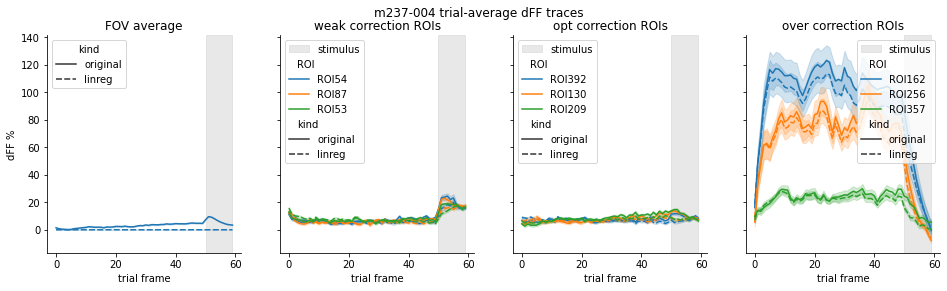

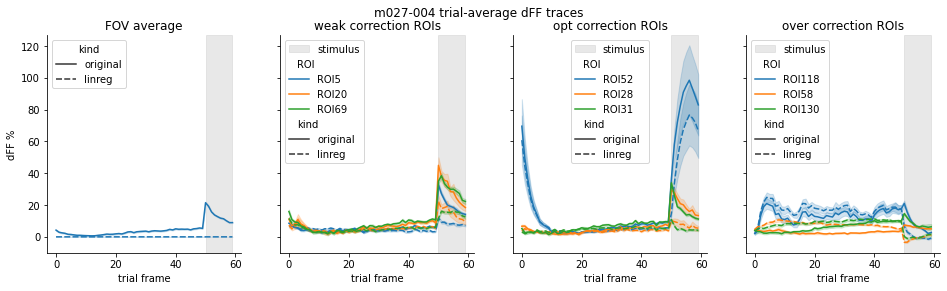

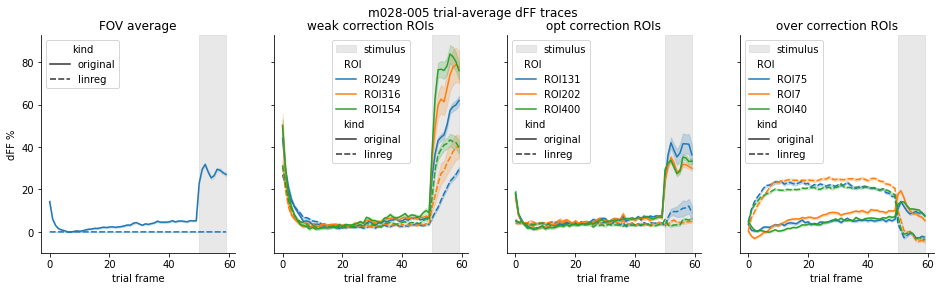

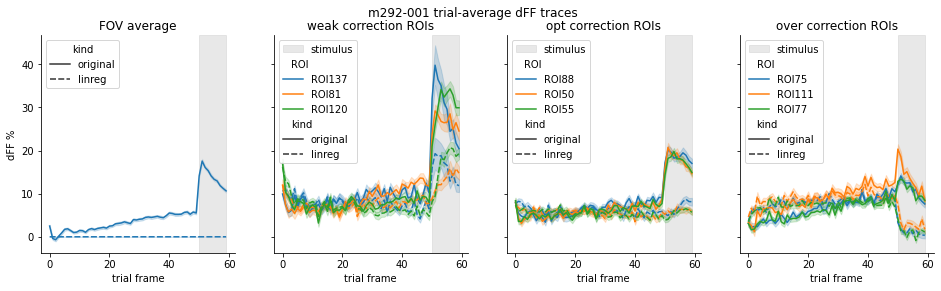

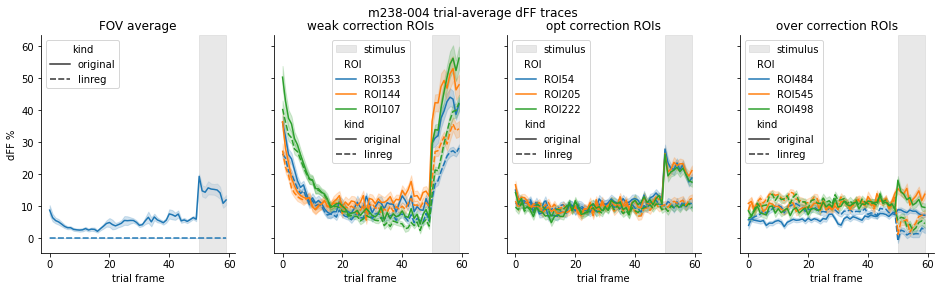

In [41]:
if analysis_type == 'ori8':

    for run, dFF in dFF_per_run.items():
        logger.info(f'working on run {run}')
        
        # Reshape dFF dataframe to add 'trial frame' level to index
        dFF = dFF[dFF.index.get_level_values('frame') <= ntrials * npertrial - 1]
        dFF['trial frame'] = dFF.index.get_level_values('frame') % npertrial
        dFF = dFF.set_index('trial frame', append=True) * 100  # convert to %

        # Define reference correction key
        refcorrkey = 'linreg'
        dFF = dFF[dFF.index.get_level_values('kind').isin(('original', refcorrkey))] 

        # print(dFF)
        # Extract ROI dFF change for that run
        ROI_dFF_change = ROI_dFF_change_per_run[run]

        # Sort ROIs by dFF change, for each stack
        sorted_ROI_dFF_change = ROI_dFF_change.groupby('kind').apply(lambda x: x.sort_values().droplevel(0))
        iROIs_by_change = {k: v.droplevel(0).index.values for k, v in sorted_ROI_dFF_change.groupby('kind')}

        fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
        fig.suptitle(f'{run} trial-average dFF traces')
        for ax in axes:
            sns.despine(ax=ax)

        ax = axes[0]
        ax.set_title('FOV average')
        sns.lineplot(
            ax=ax,
            data=dFF['FOV'].rename('dFF %').reset_index(),
            x='trial frame',
            y='dFF %',
            style='kind',
            errorbar='se',
        )
        ax.axvspan(nframes_nostim, npertrial - 1, color='lightgrey', alpha=0.5, label='stimulus')

        # Gather indexes of ROIs for which correction is too weak, optimal or too strong
        nROIs_plt = 3
        iROIs_dict = {
            'weak': sorted_ROI_dFF_change.loc[refcorrkey].tail(nROIs_plt).index.values,
            'opt': sorted_ROI_dFF_change.loc[refcorrkey].abs().sort_values().head(nROIs_plt).index.values,
            'over': sorted_ROI_dFF_change.loc[refcorrkey].head(nROIs_plt).index.values,
        }

        # Plot F and dFF traces
        for i, (k, iROIs) in enumerate(iROIs_dict.items()):
            ROIkeys = [f'ROI{i + 1}' for i in iROIs]
            tmp = dFF[ROIkeys]
            tmp.columns.name = 'ROI'
            tmp = tmp.stack().rename('dFF %').reset_index()

            ax = axes[i + 1]
            ax.set_title(f'{k} correction ROIs')
            ax.axvspan(nframes_nostim, npertrial - 1, color='lightgrey', alpha=0.5, label='stimulus')
            sns.lineplot(
                ax=ax,
                data=tmp,
                x='trial frame',
                y='dFF %',
                hue='ROI',
                style='kind',                
                estimator='mean',
                errorbar='se',
            )
        
        for ax in axes[1:]:
            ax.set_ylabel('')

        figs[f'dFF trial-avg traces {run}'] = fig


### Save figures

In [42]:
save_figs_book(figsdir, figs, suffix=analysis_type)

 2026/05/13 22:29:22: saving figures in /Users/tlemaire/Documents/data/hemo2p/DVAA datasets/figs/figs_ori8_20260513.pdf:


100%|██████████| 38/38 [00:09<00:00,  4.19it/s]


### Log completion

In [15]:
tend_analysis = time.perf_counter()
elapsed_time = tend_analysis - tstart_analysis
logger.info(f'{analysis_type} DVAA analysis completed successfully in {elapsed_time:.2f} seconds.')

 2025/12/18 20:17:28: opto_constrict DVAA analysis completed successfully in 38.85 seconds.
